In [1]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt

In [2]:
IMAGE_SIZE = 155
BATCH_SIZE = 4
CHANNEL = 3
EPOCHS = 3 
n_classes = 38

In [3]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "plantvillage_dataset/color", 
    shuffle=True,
    image_size = (IMAGE_SIZE, IMAGE_SIZE),
    batch_size = BATCH_SIZE
)

Found 54305 files belonging to 38 classes.


In [4]:
class_names = dataset.class_names
class_names
len(dataset)

13577

In [5]:

print(f"Number of classes: {len(class_names)}")
print(f"Number of batches: {len(dataset)}")
print("\nFirst 10 classes:")
for i, class_name in enumerate(class_names[:10], 1):
    print(f"{i}. {class_name}")

Number of classes: 38
Number of batches: 13577

First 10 classes:
1. Apple___Apple_scab
2. Apple___Black_rot
3. Apple___Cedar_apple_rust
4. Apple___healthy
5. Blueberry___healthy
6. Cherry_(including_sour)___Powdery_mildew
7. Cherry_(including_sour)___healthy
8. Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
9. Corn_(maize)___Common_rust_
10. Corn_(maize)___Northern_Leaf_Blight


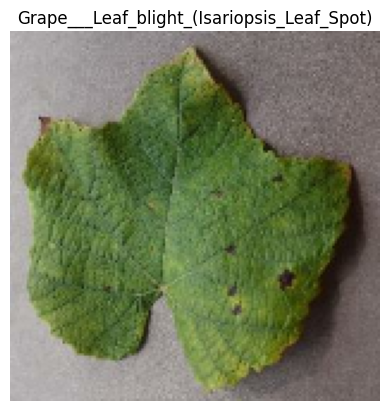

In [6]:
for image_batch, label_batch in dataset.take(1):
    plt.imshow(image_batch[0].numpy().astype("uint8"))
    plt.title(class_names[label_batch[0]])
    plt.axis("off")

In [7]:
train_size = 0.8
len(dataset)*train_size

10861.6

In [8]:
train_ds =dataset.take(int(len(dataset)*train_size))
len(train_ds)


10861

In [9]:
test_ds = dataset.skip(int(len(dataset)*train_size))
len(test_ds)

2716

In [10]:
val_size = 0.1
len(dataset) * val_size

1357.7

In [11]:
val_ds = test_ds.skip(int(len(dataset)*val_size))
len(val_ds)

1359

In [12]:
test_ds = test_ds.skip(int(len(dataset)*val_size))
len(test_ds)

1359

In [13]:
def get_dataset_partition_tf(ds, train_split = 0.8, val_split = 0.1 , test_split = 0.1, shuffle=True, shuffle_size=1000):
    ds_size = len(ds)
    if shuffle :
        ds = ds.shuffle(shuffle_size, seed=12)
    
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    
    train_ds = ds.take(train_size)

    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).take(val_size)
    return train_ds , val_ds , test_ds



In [14]:
train_ds, val_ds, test_ds = get_dataset_partition_tf(dataset)

In [15]:
len(train_ds)

10861

In [16]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)
val_ds =  val_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)

In [17]:
resize_and_rescaling = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE,IMAGE_SIZE),
    layers.Rescaling(1.0/255)
])

In [18]:
data_augmentation =tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
])

In [19]:
model = models.Sequential([
    layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNEL)),
    resize_and_rescaling,
    data_augmentation,
    
    layers.Conv2D(32,(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(64,(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(n_classes, activation='softmax')
])

In [20]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 155, 155, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 155, 155, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 153, 153, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 76, 76, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 74, 74, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 35, 35, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 5, 5, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │        33,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 307,878 (1.17 MB)

 Trainable params: 306,214 (1.17 MB)

 Non-trainable params: 1,664 (6.50 KB)

In [21]:
model.compile(
    optimizer ='adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = False),
    metrics = ['accuracy']
)

In [22]:
history = model.fit(
    train_ds,
    epochs =EPOCHS, 
    batch_size = BATCH_SIZE,
    verbose=1, 
    validation_data = val_ds
)

Epoch 1/3
10861/10861 ━━━━━━━━━━━━━━━━━━━━ 499s 45ms/step - accuracy: 0.1882 - loss: 3.0828 - val_accuracy: 0.3145 - val_loss: 2.5165
Epoch 2/3
10861/10861 ━━━━━━━━━━━━━━━━━━━━ 499s 45ms/step - accuracy: 0.1882 - loss: 3.0828 - val_accuracy: 0.3145 - val_loss: 2.5165
Epoch 2/3
10861/10861 ━━━━━━━━━━━━━━━━━━━━ 476s 44ms/step - accuracy: 0.2619 - loss: 2.6674 - val_accuracy: 0.4199 - val_loss: 2.0435
Epoch 3/3
10861/10861 ━━━━━━━━━━━━━━━━━━━━ 476s 44ms/step - accuracy: 0.2619 - loss: 2.6674 - val_accuracy: 0.4199 - val_loss: 2.0435
Epoch 3/3
10861/10861 ━━━━━━━━━━━━━━━━━━━━ 529s 49ms/step - accuracy: 0.3315 - loss: 2.3990 - val_accuracy: 0.4889 - val_loss: 1.7514
10861/10861 ━━━━━━━━━━━━━━━━━━━━ 529s 49ms/step - accuracy: 0.3315 - loss: 2.3990 - val_accuracy: 0.4889 - val_loss: 1.7514


In [23]:
score = model.evaluate(test_ds) 


1357/1357 ━━━━━━━━━━━━━━━━━━━━ 72s 15ms/step - accuracy: 0.4989 - loss: 1.7913


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
Predicted class: Strawberry___Leaf_scorch
Actual class: Potato___Early_blight
Probability: 0.25547013


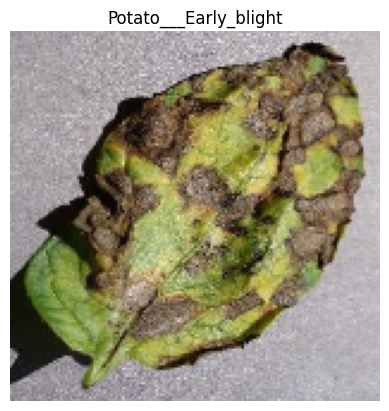

In [32]:
import numpy as np
for image_batch, label_batch in test_ds.take(1):
    plt.imshow(image_batch[0].numpy().astype("uint8"))
    plt.title(class_names[label_batch[0]])
    plt.axis("off")
    predictions = model.predict(image_batch)
    predicted_class = np.argmax(predictions[0])
    print("Predicted class:", class_names[predicted_class])
    print("Actual class:", class_names[label_batch[0]])
    print("Probability:", np.max(predictions[0]))